In [25]:
%cd /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough

import argparse
import inspect
import json
import os
import pickle
import socket
import subprocess
import warnings
import random
import math
import librosa
import shutil
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import lightning as L
from torch.utils.data import WeightedRandomSampler
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers.tensorboard import TensorBoardLogger
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

import commons
import models
import utils
import losses
import lightning_wrapper
from cough_datasets import CoughDatasets, CoughDatasetsCollate, CoughDatasetsProcessorCollate, CoughDiseaseBinaryBatchSampler, CoughDetectionRatioBatchSampler, PatientBatchSampler

torch.set_float32_matmul_precision("medium")
cmap = cm.get_cmap("viridis")

def minmax_norm(x, eps=1e-8):
    return (x - x.min()) / (x.max() - x.min() + eps)

/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough


/tmp/ipykernel_447595/3617807414.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


In [141]:
parser = argparse.ArgumentParser()
parser.add_argument("--init", action="store_true")
parser.add_argument("--eval", action="store_true")
parser.add_argument("--model_name", type=str, default="try_wavlmlora_downstream")
parser.add_argument("--config_path", type=str, default="configs/ssl_finetuning.json")

parser.add_argument("--feature_dim", type=int)
parser.add_argument("--pooling_model", type=str)
parser.add_argument("--feature_type", type=str)
parser.add_argument("--delta_feature", action=argparse.BooleanOptionalAction, default=None)
parser.add_argument("--deltadelta_feature", action=argparse.BooleanOptionalAction, default=None)

args = parser.parse_args(["--init", "--model_name", "dev", "--pooling_model", "ResNet34SplitdeltaClassifier", "--feature_type", "gammmaspectogram", 
                          "--feature_dim", "80", "--delta_feature", "--deltadelta_feature", "--config_path", "configs/general.json"])

model_dir = os.path.join("./logs", args.model_name)
os.makedirs(model_dir, exist_ok=True)

config_path = args.config_path if args.init else os.path.join(model_dir, "config.json")
with open(config_path) as f:
    config = json.load(f)

overrides = {
    ("model", "feature_dim"): args.feature_dim,
    ("model", "pooling_model"): args.pooling_model,
    ("data", "feature_type"): args.feature_type,
    ("data", "delta_feature"): args.delta_feature,
    ("data", "deltadelta_feature"): args.deltadelta_feature,
}

for (section, key), value in overrides.items():
    if value is not None:
        config.setdefault(section, {})[key] = value

with open(os.path.join(model_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

hps = utils.HParams(**config)
hps.model_dir = model_dir
hps.data.mae_training = hps.train.mae_training
hps.data.ssccl_training = hps.train.ssccl_training

# hps.data.acoustic_feature = False
# hps.data.mean_std_norm = False
# =============================================================
# SECTION: Loading Data
# =============================================================
df_train = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/{hps.data.metadata_csv}.train')
df_test = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/{hps.data.metadata_csv}.test')

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train = df_train[hps.data.column_order]
df_test = df_test[hps.data.column_order]

collate_fn = CoughDatasetsCollate(hps.data.many_class)
target_labels = df_train[hps.data.target_column]

train_idx, val_idx = train_test_split(
    df_train.index.to_numpy(),
    test_size=0.2,
    random_state=42,
    stratify=target_labels
)
splitter = [(train_idx, val_idx)]
num_folds = 1

for fold, (train_idx, val_idx) in enumerate(splitter):
    train_fold = df_train.iloc[train_idx].reset_index(drop=True)
    val_fold = df_train.iloc[val_idx].reset_index(drop=True)


positive_idx = train_fold.index[train_fold[hps.data.target_column] == 1].tolist()
negative_idx = train_fold.index[train_fold[hps.data.target_column] == 0].tolist()

num_pos = len(positive_idx)
num_neg = len(negative_idx)

# inverse-frequency class weights
pos_weight = 1.0 / num_pos
neg_weight = 1.0 / num_neg

# initialize all weights to zero
sample_weights = torch.zeros(len(train_fold), dtype=torch.double)

# assign weights by index
sample_weights[positive_idx] = pos_weight
sample_weights[negative_idx] = neg_weight

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

class_weights_tensor = utils.compute_class_weights(train_fold, hps.data.target_column)
if hps.data.acoustic_feature and hps.data.mean_std_norm == True:
    utils.compute_spectrogram_stats_from_dataset(
        train_fold, 
        hps.data, 
        pickle_path=f"{hps.model_dir}/wav_stats_fold_{fold}.pickle"
    )
else:
    utils.compute_wav_stats(
        train_fold, 
        "path_file", 
        pickle_path=f"{hps.model_dir}/wav_stats_fold_{fold}.pickle"
    )

train_dataset = CoughDatasets(train_fold.values, hps.data,
                            wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{fold}.pickle", train=True)
val_dataset = CoughDatasets(val_fold.values, hps.data,
                            wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{fold}.pickle", train=False)

train_loader = DataLoader(train_dataset, num_workers=28, shuffle=False, sampler=sampler, batch_size=hps.train.batch_size,
                            pin_memory=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, num_workers=28, shuffle=True, batch_size=hps.train.batch_size,
                        pin_memory=True, collate_fn=collate_fn)

In [142]:
batch = next(iter(train_loader))
_, audio1, audio2, attention_masks, dse_ids, [patient_ids, _, tabular_ids] = batch
labels = np.argmax(dse_ids.cpu().numpy(), axis=-1)

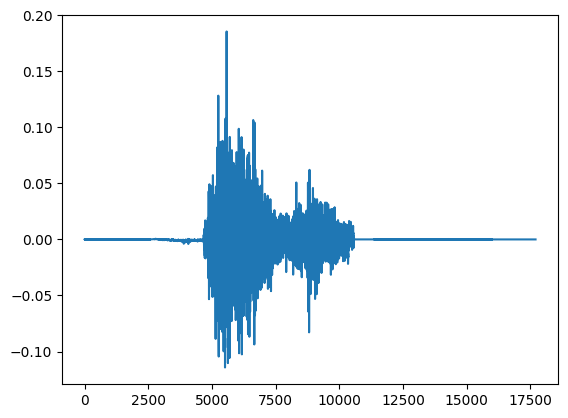

In [ ]:
selected_index = random.randint(0, len(audio1) - 1)
audio_np = audio1[selected_index].cpu().numpy().reshape(-1)

plt.plot(audio_np)

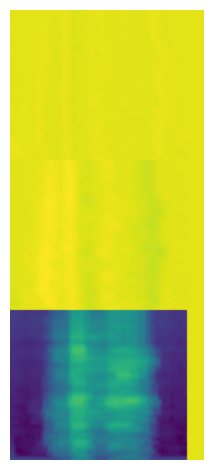

In [ ]:
selected_index = random.randint(0, len(audio1) - 1)
audio_np = audio1[selected_index].cpu().numpy()

audio_np = minmax_norm(audio_np)
audio_np = np.flipud(audio_np)
mel_rgb = cmap(audio_np)[..., :3]

plt.imshow(mel_rgb)
plt.axis('off')
plt.tight_layout()
plt.show()